# Dichtheidsgebaseerde clustering van netmeetstations met PROC MODECLUS


## Samenvatting

Een elektriciteitsdistributiebedrijf gebruikt PROC MODECLUS om niet-parametrische,
dichtheidsgebaseerde clusters te vinden tussen zijn netmeetstations (onderstations
en voedingssensoren) op basis van uitsluitend hun kaartcoördinaten. MODECLUS schat
een dichtheidsoppervlak over de locaties en behandelt clusters als gebieden met
hoge dichtheid, gescheiden door gebieden met lage dichtheid. Uitgevoerd op 90
gesimuleerde locaties met een straal van een uniforme kernel van 3 km, worden de
drie dichte dienstgebieden die we in de gegevens hebben ingebouwd teruggevonden
als de drie grootste clusters (24, 24 en 21 locaties), terwijl de verspreide
landelijke locaties in ijle gebieden vallen en afsplitsen in hun eigen micro-
clusters van één of twee locaties. Die verzameling geïsoleerde locaties is het
operationele resultaat: een kandidatenlijst van afgelegen bezittingen voor het
team dat de investeringsplanning doet.


## Gegevensbronnen

| Dataset | Rijen | Beschrijving |
|---------|------|-------------|
| `grid_sites` | 90 | Synthetische netmeetstations van een elektriciteitsdistributiebedrijf, inline gegenereerd met `call streaminit(70531)` en `rand()`. Drie dichte dienstgebieden (StadsKern, Voorstad, Industrieterrein) getrokken uit bivariate normale verdelingen rond afzonderlijke kaartcentroïden, plus 22 verspreide landelijke locaties uniform getrokken over het gebied. |

| Variabele | Type | Beschrijving |
|----------|------|-------------|
| `site_id` | Num | Uniek identificatienummer van het meetstation (1-90). |
| `region` | Char | Planninglabel dat vastlegt hoe elke locatie is gegenereerd (StadsKern, Voorstad, Industrieterrein, Landelijk); buiten de clustering gehouden. |
| `x_km`, `y_km` | Num | Locatie van het meetstation in kilometers op het planningsraster van het bedrijf; de clustervariabelen. |
| `peak_load_mw` | Num | Waargenomen jaarlijkse piekbelasting (MW) op de locatie; meegenomen voor interpretatie achteraf. |


# Dichtheidsgebaseerde clustering van netmeetstations

Een regionaal elektriciteitsdistributiebedrijf beheert een netwerk van
**meetstations** - onderstations en voedingssensoren - verspreid over zijn
verzorgingsgebied. Planners willen deze locaties groeperen in natuurlijke
**dienstgebieden** op basis van uitsluitend geografie, zonder vooraf te
bepalen hoeveel groepen er bestaan, en **geïsoleerde landelijke bezittingen**
identificeren die niet tot een dicht gebied behoren.

`PROC MODECLUS` is hier goed voor geschikt: het voert *niet-parametrische,
dichtheidsgebaseerde* clustering uit. Het schat een dichtheidsfunctie over de
locaties en behandelt clusters vervolgens als gebieden met hoge locatie-
dichtheid, gescheiden door gebieden met lage dichtheid. IJle uitschieters
komen terecht in hun eigen kleine clusters in plaats van te worden opgenomen
in een dienstgebied - precies het gedrag dat we willen om afgelegen locaties
te signaleren.

Deze notebook:
1. Genereert een realistisch synthetisch netwerk van 90 locaties.
2. Schat de locatiedichtheid met een **uniforme kernel** en scant de
   gladstrijkingsstraal `R=` om te bevestigen dat de teruggevonden
   dienstgebieden stabiel zijn.
3. Legt een werkstraal vast, schrijft een `OUT=`-dataset met de dichtheid en
   het clusterlabel van elke locatie, en brengt het resultaat in kaart.


## Stap 1 -- Genereer een synthetisch netwerk van meetstations

We simuleren 90 locaties. Drie dichte **dienstgebieden** worden getrokken uit
bivariate normale verdelingen rond afzonderlijke kaartcentroïden (StadsKern
bij (12, 30), Voorstad bij (30, 15), Industrieterrein bij (20, 42)), wat
compacte, dichte blobs van 24, 24 en 20 locaties oplevert. Een vierde
verzameling van 22 **landelijke** locaties wordt uniform getrokken over het
gebied, wat de ijle, verspreide locaties oplevert die een bedrijf als
geïsoleerd zou behandelen.

Het label `region` legt vast hoe elke locatie is gegenereerd; we houden het
opzettelijk **buiten** de clustering zodat MODECLUS de structuur uitsluitend
op basis van coördinaten herontdekt. `peak_load_mw` wordt meegenomen voor
latere interpretatie.


In [1]:
GEGEVENS grid_sites;
   CALL streaminit(70531);
   LENGTE region $ 16;

   /* Dicht stedelijk dienstgebied */
   DOE site_id = 1 TOT 24;
      region = 'StadsKern';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      UITVOER;
   EINDE;

   /* Voorstedelijk dienstgebied */
   DOE site_id = 25 TOT 48;
      region = 'Voorstad';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      UITVOER;
   EINDE;

   /* Industrieterrein (hogere piekbelasting) */
   DOE site_id = 49 TOT 68;
      region = 'Industrieterrein';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      UITVOER;
   EINDE;

   /* Verspreide landelijke locaties (ijl, lage belasting) */
   DOE site_id = 69 TOT 90;
      region = 'Landelijk';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      UITVOER;
   EINDE;
UITVOEREN;

TITEL 'Synthetische netmeetstations';
PROCEDURE GEMIDDELDEN GEGEVENS=grid_sites n mean std MIN MAX maxdec=2;
   KLASSE region;
   VARIABELE x_km y_km peak_load_mw;
   label region="Regio" x_km="X (km)" y_km="Y (km)" peak_load_mw="Piekbelasting (MW)";
UITVOEREN;


                                              Synthetische netmeetstations                                              

                                                  The MEANS Procedure

                                            Analysis Variable : x_km X (km)

        Regio                     N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------------
        Industrieterrein             20          20.36           0.96          18.52          21.53
        Landelijk                    22          29.79          10.62          11.06          47.45
        StadsKern                    24          12.07           1.34           8.65          14.42
        Voorstad                     24          29.96           1.73          26.51          33.60
        -------------------------------------------------------------------------------------------

                             


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Synthetische netmeetstations.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


De gemiddelden bevestigen drie krappe dienstgebieden en één diffuse groep. De
drie dichte regio's hebben kleine standaarddeviaties in coördinaten (ongeveer
1-1,7 km op elke as) rond goed gescheiden centroïden, terwijl de landelijke
groep zich over het hele raster verspreidt (standaarddeviaties boven 10 km op
beide assen). Ook de piekbelasting onderscheidt de dienstgebieden -
Industrieterrein-locaties hebben gemiddeld ongeveer 6 MW, StadsKern ongeveer
4,6 MW, Voorstad ongeveer 2,7 MW, en landelijke locaties ongeveer 1,5 MW -
wat nuttige context biedt zodra de geografische clusters bekend zijn.


## Stap 2 -- Dichtheidsclustering met uniforme kernel en een straal-scan

Dichtheidsschatting met een uniforme kernel gebruikt een **straal `R=`**:
elke locatie binnen `R` kilometer draagt bij aan de lokale dichtheid van een
locatie. Een kleine `R` geeft een grillige dichtheid die het gebied
fragmenteert; een grote `R` strijkt te veel glad en voegt dienstgebieden
samen. Een SAS-expert vertrouwt nooit op één enkele waarde - ze scannen een
reeks stralen en zoeken naar een clusteraantal dat **stabiel** is, waarbij de
dichte dienstgebieden blijven bestaan terwijl alleen het aantal verspreide
singletons verschuift.

Hier selecteert `M=1` clustermethode 1 (de standaard niet-parametrische
methode), en vragen we in één aanroep stralen `R=2,5 tot 4 in stappen van
0,5` op. MODECLUS voert de analyse eenmaal per straal uit en rapporteert het
aantal clusters voor elke straal. `SHORT` onderdrukt de uitgebreide
per-cluster-statistieken.


In [2]:
TITEL 'Dichtheidsclustering met uniforme kernel van netmeetstations';
title2 'Straal-scan R = 2,5 tot 4,0 km';

PROCEDURE modeclus GEGEVENS=grid_sites m=1 r=2.5 to 4 by 0.5 short;
   VARIABELE x_km y_km;
   id site_id;
UITVOEREN;


                              Dichtheidsclustering met uniforme kernel van netmeetstations                              
                                             Straal-scan R = 2,5 tot 4,0 km                                             


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to Dichtheidsclustering met uniforme kernel van netmeetstations.
NOTE: Option TITLE2 changed to Straal-scan R = 2,5 tot 4,0 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Het clusteraantal verschuift slechts licht over de scan -- 23 clusters bij
`R=2,5`, 22 bij `R=3,0`, 19 bij `R=3,5`, en 18 bij `R=4,0`. De hoge ruwe
aantallen komen van de verspreide landelijke locaties: elke geïsoleerde
locatie zit in zijn eigen ijle omgeving en vormt een cluster van één locatie,
dus de meeste van de 18-23 "clusters" zijn singletons. Wat daaronder
constant blijft, is de structuur die ertoe doet - de drie dichte
dienstgebieden blijven bij elke straal drie grote, goed gescheiden clusters.
Naarmate `R` breder wordt, versmelten enkele verspreide singletons met een
buur of een nabijgelegen dienstgebied, wat verklaart waarom het totale
aantal langzaam afneemt in plaats van wild te schommelen. Die stabiliteit is
het signaal dat de driegebieden-oplossing echt is en geen artefact van één
bandbreedte.


## Stap 3 -- Definitieve geclusterde oplossing voor het in kaart brengen

Nu we hebben gezien dat de drie dienstgebieden stabiel zijn over de scan,
leggen we een enkele werkstraal vast (`R=3` km) en vragen we de optie
**ALL** op voor de volledige per-cluster-weergave, plus **OUT=** om de
oorspronkelijke coördinaten samen met de schatting van **DENSITY** en de
toewijzing van **CLUSTER** weg te schrijven zodat we het resultaat in kaart
kunnen brengen. Clusters worden genummerd in aflopende volgorde van
modusdichtheid, dus de dichtste dienstgebieden zijn clusters 1, 2 en 3, en
de ijle locaties krijgen de hogere nummers.


In [3]:
TITEL 'Definitieve dichtheidsgebaseerde clusteroplossing';
title2 'Uniforme kernel, R = 3 km';

PROCEDURE modeclus GEGEVENS=grid_sites m=1 r=3 out=join_out ALL;
   VARIABELE x_km y_km;
   id site_id;
UITVOEREN;


                                   Definitieve dichtheidsgebaseerde clusteroplossing                                    
                                               Uniforme kernel, R = 3 km                                                


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7    1          70      0.000393
      


NOTE: Option TITLE changed to Definitieve dichtheidsgebaseerde clusteroplossing.
NOTE: Option TITLE2 changed to Uniforme kernel, R = 3 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


De clustersamenvatting maakt de structuur expliciet. De `R=3`-oplossing
levert **22 clusters** op, maar deze zijn sterk gelaagd naar dichtheid:

- **Cluster 1** -- 24 locaties, modusdichtheid ongeveer 0,0090 (het
  StadsKern-dienstgebied).
- **Cluster 2** -- 24 locaties, modusdichtheid ongeveer 0,0079 (het
  Voorstad-dienstgebied).
- **Cluster 3** -- 21 locaties, modusdichtheid ongeveer 0,0079 (het
  Industrieterrein-dienstgebied; het neemt één landelijke locatie mee die
  toevallig op de rand ervan viel).
- **Clusters 4-22** -- een groep van drie locaties en achttien clusters van
  één locatie, allemaal met een modusdichtheid van ongeveer 0,0004, ruwweg
  twintig keer ijler dan de dienstgebieden.

De drie dichte dienstgebieden vertegenwoordigen 69 van de 90 locaties; de
overige 21 locaties zijn de verspreide landelijke bezittingen, die elk alleen
of bijna alleen staan in een omgeving met lage dichtheid. Dichtheid, niet een
vooraf bepaald aantal clusters, trekt de grens tussen een dienstgebied en een
geïsoleerde locatie.


## Stap 4 -- Breng de clusters in kaart

We labelen elke locatie op basis van of deze in een van de drie dichte
dienstgebieden viel (`cluster <= 3`) of in een ijl microcluster, en zetten
vervolgens elke locatie op zijn kaartcoördinaten, gekleurd naar die status.
Dit is het perspectief van de planner: dichte dienstgebieden om te beheren
als verzorgingsgebieden, en geïsoleerde locaties om apart te worden
behandeld.


                                  Teruggevonden dienstgebieden en geïsoleerde locaties                                  
                                   Dichtheidsclustering met uniforme kernel, R = 3 km                                   




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to Teruggevonden dienstgebieden en geïsoleerde locaties.
NOTE: Option TITLE2 changed to Dichtheidsclustering met uniforme kernel, R = 3 km.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


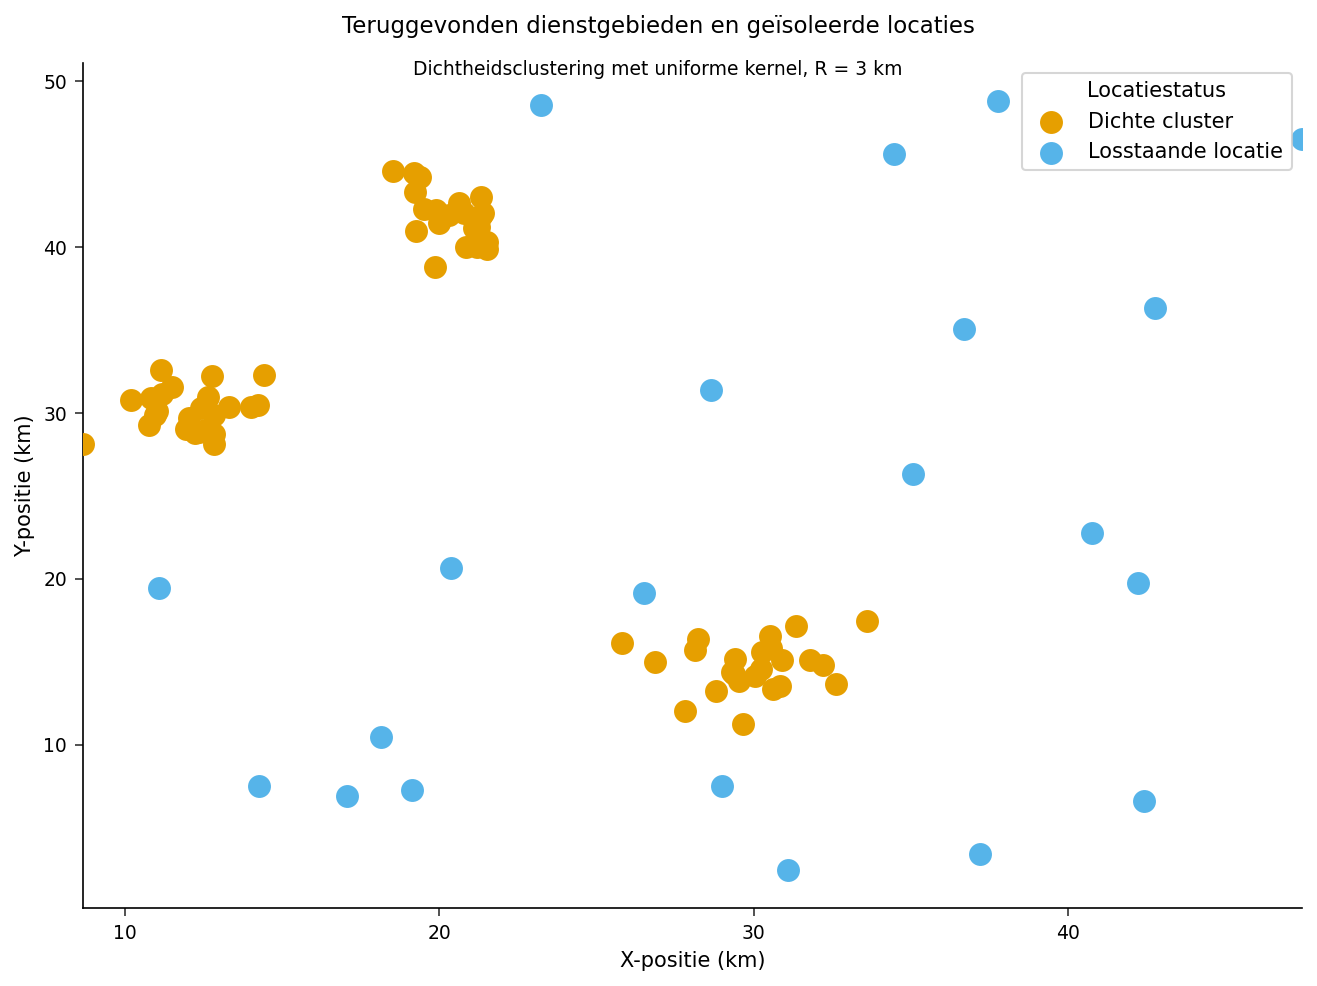

In [4]:
GEGEVENS mapped;
   INSTELLEN join_out;
   LENGTE status $ 20;
   ALS CLUSTER <= 3 DAN status = 'Dichte cluster';
   ANDERS status = 'Losstaande locatie';
UITVOEREN;

TITEL 'Teruggevonden dienstgebieden en geïsoleerde locaties';
title2 'Dichtheidsclustering met uniforme kernel, R = 3 km';
PROCEDURE SGPLOT GEGEVENS=mapped;
   SCATTER x=x_km y=y_km / GROUP=status markerchar=CLUSTER
                           MARKERATTRS=(size=10);
   XAXIS label='X-positie (km)';
   YAXIS label='Y-positie (km)';
   keylegend / TITEL='Locatiestatus';
UITVOEREN;

TITEL;


## Interpretatie van de resultaten

**Wat MODECLUS heeft gevonden.** Uitsluitend gestuurd door `(x_km, y_km)`
vindt de procedure de drie dichte dienstgebieden terug die we in de gegevens
hebben ingebouwd - de blobs StadsKern, Voorstad en Industrieterrein - als de
drie grootste, dichtste clusters (24, 24 en 21 locaties). De verspreide
landelijke locaties, uniform getrokken over het gebied, vallen in ijle
gebieden en splitsen af in hun eigen clusters van één of twee locaties in
plaats van te worden opgenomen in een dienstgebied. Op de kaart zijn dat de
punten die gescheiden zijn van de drie krappe blobs. Die geïsoleerde
verzameling is het operationele resultaat: een kandidatenlijst van
afgelegen bezittingen voor het team dat de investeringsplanning doet.

**Waarom de gladstrijkingsscan ertoe doet.** Geen enkele `R` is
doorslaggevend voor niet-parametrische dichtheidsclustering. Door
`R=2,5 tot 4 in stappen van 0,5` te scannen kunnen we bevestigen dat de
dienstgebieden *stabiel* zijn over gladstrijkingsniveaus, in plaats van een
artefact van één bandbreedte. Over de scan verschuift het clusteraantal
slechts van 23 naar 18, en de verandering zit volledig in het aantal
verspreide singletons - de drie dichte dienstgebieden blijven de hele tijd
bestaan. Waar de structuur zo stabiel bleef, hebben we een verdedigbare
oplossing; als het aantal wild had geschommeld, zou de structuur broos zijn
geweest en zou deze geen investeringsbeslissingen moeten sturen.

**Dichtheid rangschikt het resultaat in lagen.** Omdat clusters worden
genummerd in aflopende volgorde van modusdichtheid, is de scheiding tussen
dienstgebieden en geïsoleerde locaties kwantitatief, niet willekeurig: de
drie dienstgebieden liggen rond een modusdichtheid van 0,008-0,009, terwijl
elke geïsoleerde locatie rond 0,0004 ligt, ongeveer twintig keer ijler. Een
planner kan een dichtheidsdrempel instellen en de geïsoleerde bezittingen
rechtstreeks aflezen van de kolommen `CLUSTER` en `DENSITY` van `join_out`.

**Praktisch gebruik.** De dataset `join_out` geeft elke locatie een
dichtheid en een clusterlabel dat vervolgwerk kan voeden - het bepalen van
de omvang van ploegen en reserveonderdelen per dienstgebied, het plannen van
inspectierondes, of het prioriteren van netverzwaring in het dichte
industriële cluster (hoogste `peak_load_mw`, ongeveer 6 MW) terwijl de
geïsoleerde landelijke locaties worden ingepland voor apart onderhoud met
lagere frequentie.

*Opmerking over synthetische gegevens:* coördinaten en belastingen zijn
gesimuleerd met een vaste seed (`call streaminit(70531)`) zodat de notebook
volledig reproduceerbaar is offline; op echte bedrijfsgegevens zou u
opgemeten locatiecoördinaten en gemeten piekbelastingen gebruiken. De exacte
clusteraantallen hangen af van de willekeurige trekking en van de gekozen
straal.
